Mount Google Drive & Unzip the Dataset

In [ ]:
from google.colab import drive
import zipfile
import os

# Mount Google Drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Path to your zip file (update this!)
zip_path = "/content/drive/MyDrive/Projects/Space Debris Collector/NCSTP_det_recog.zip"

# Destination folder in Colab's temporary storage
extract_dir = "/content/NCSTP_dataset"
os.makedirs(extract_dir, exist_ok=True)

# Unzip
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_dir)
print("✅ Unzipping completed.")
print("Contents of the extracted folder:")
!ls -la {extract_dir}

✅ Unzipping completed.
Contents of the extracted folder:
total 12
drwxr-xr-x 3 root root 4096 Mar 24 12:12 .
drwxr-xr-x 1 root root 4096 Mar 24 12:12 ..
drwxr-xr-x 6 root root 4096 Mar 24 12:14 SNT_coco


In [ ]:
!pip install pycocotools matplotlib numpy pillow

Locate the SNT_coco Folder and Define Paths

In [ ]:
import os

base_dir = os.path.join(extract_dir, "SNT_coco")

# Annotation files
ann_train = os.path.join(base_dir, "annotations", "train.json")
ann_val   = os.path.join(base_dir, "annotations", "val.json")
ann_test  = os.path.join(base_dir, "annotations", "test.json")

# Image directories
img_train_dir = os.path.join(base_dir, "train")
img_val_dir   = os.path.join(base_dir, "val")
img_test_dir  = os.path.join(base_dir, "test")

# Quick check that files exist
print("Train annotations exist:", os.path.exists(ann_train))
print("Train images folder exist:", os.path.exists(img_train_dir))

Train annotations exist: True
Train images folder exist: True


# **Data Preprocessing**

Load COCO Annotations and Explore Basic Info

In [ ]:
from pycocotools.coco import COCO

# Load training annotations
coco_train = COCO(ann_train)

# Get category information
cat_ids = coco_train.getCatIds()
categories = coco_train.loadCats(cat_ids)
cat_names = [cat['name'] for cat in categories]
print("📁 Categories:", cat_names)

# Number of images
img_ids = coco_train.getImgIds()
print(f"📷 Number of training images: {len(img_ids)}")

# Number of annotations (object instances)
ann_ids = coco_train.getAnnIds()
print(f"🔖 Number of training annotations: {len(ann_ids)}")

loading annotations into memory...
Done (t=2.85s)
creating index...
index created!
📁 Categories: ['Cubesat', 'Cylindrical_satellite', 'GEO_communication_satellite', 'LEO_communication_satellite', 'Navigation_satellite', 'SAR_satellite', 'Single_panel_Earth_observation_satellite', 'Symmetrical_Earth_Observation_Satellite', 'Space_Probe', 'Space_Telescope', 'spacedebris', 'spacerock']
📷 Number of training images: 140000
🔖 Number of training annotations: 140000


Visualise Sample Images with Bounding Boxes

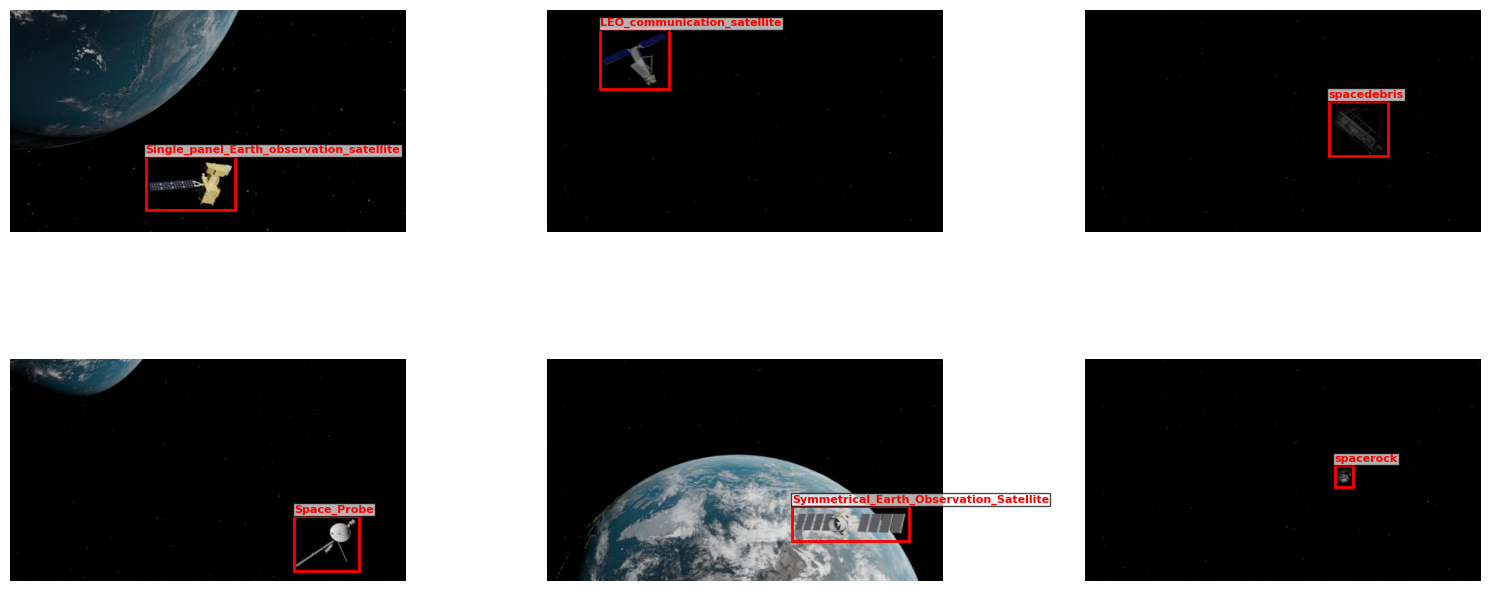

In [ ]:
import random
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image

def show_image_with_boxes(coco, img_id, img_dir, ax=None):
    """Display an image with its COCO bounding boxes."""
    img_info = coco.loadImgs(img_id)[0]
    img_path = os.path.join(img_dir, img_info['file_name'])
    image = Image.open(img_path)

    if ax is None:
        fig, ax = plt.subplots(1, figsize=(10, 6))

    ax.imshow(image)

    ann_ids = coco.getAnnIds(imgIds=img_id)
    anns = coco.loadAnns(ann_ids)

    for ann in anns:
        bbox = ann['bbox']          # [x, y, width, height]
        x, y, w, h = bbox
        cat_name = coco.loadCats([ann['category_id']])[0]['name']

        rect = patches.Rectangle((x, y), w, h, linewidth=2, edgecolor='red', facecolor='none')
        ax.add_patch(rect)
        ax.text(x, y-5, cat_name, color='red', fontsize=8, weight='bold',
                bbox=dict(facecolor='white', alpha=0.7, pad=1))

    ax.axis('off')
    return ax

# Display a grid of 6 random images
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

sample_ids = random.sample(img_ids, 6)
for i, img_id in enumerate(sample_ids):
    show_image_with_boxes(coco_train, img_id, img_train_dir, axes[i])

plt.tight_layout()
plt.show()

Class Distribution

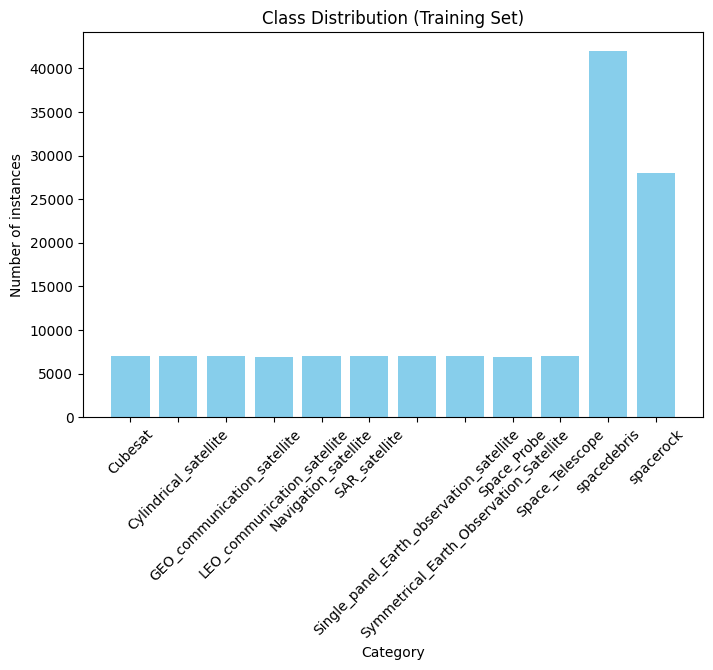

In [ ]:
# Count annotations per category
cat_count = {cat['id']: 0 for cat in categories}
for ann in coco_train.loadAnns(ann_ids):
    cat_count[ann['category_id']] += 1

# Prepare data for plotting
cat_names_plot = [cat['name'] for cat in categories]
counts = [cat_count[cat['id']] for cat in categories]

plt.figure(figsize=(8,5))
plt.bar(cat_names_plot, counts, color='skyblue')
plt.xlabel('Category')
plt.ylabel('Number of instances')
plt.title('Class Distribution (Training Set)')
plt.xticks(rotation=45)
plt.show()

**Class Distribution Analysis (Training Set)**

The bar chart above visualizes the number of annotated instances per category in the training set. Key observations:

- **Dominance of Debris**  
  The `spacedebris` and `spacerock` class has the highest number of instances, indicating that the dataset contains significantly more debris examples than any single satellite type. This is advantageous for our binary detection task because the model will have abundant positive samples to learn from.

- **Varied Satellite Representation**  
  Satellite categories range from medium‑frequency (e.g., `CubeSat`, `GEO_communication_satellite`) to rare ones (e.g., `Space_Telescope`). The diversity among satellite types ensures the model is exposed to a wide variety of “non‑debris” appearances, which helps it generalize better when distinguishing debris from different satellite designs.

- **Implication for Binary Classification**  
  Since debris is the majority class, the dataset is naturally biased toward the positive class. While this reduces the risk of missing debris, it may cause the model to become overconfident and produce false positives (labeling satellites as debris). To counter this, we still use class‑weighted loss or balanced sampling during training to keep the model attentive to both classes.

- **Why We Still Balanced the Subset**  
  Even though debris is abundant, we intentionally created a balanced training subset (equal numbers of debris and non‑debris) to ensure the model does not simply learn to always predict “debris.” By also sampling non‑debris images evenly across satellite types, we avoid overfitting to a few common satellite classes.


Bounding Box Size Analysis

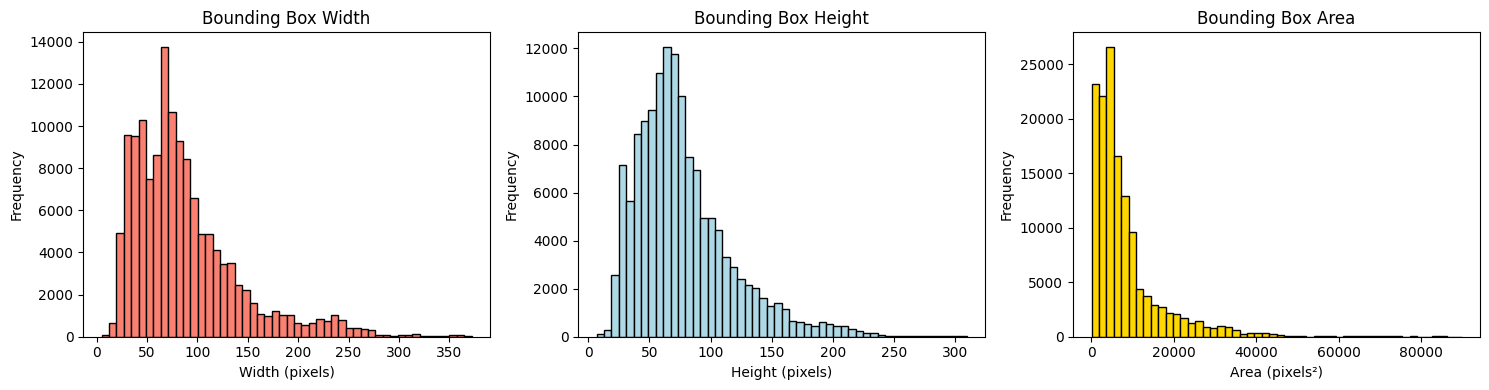

In [ ]:
widths = []
heights = []
areas = []

for ann in coco_train.loadAnns(ann_ids):
    bbox = ann['bbox']   # [x, y, w, h]
    w, h = bbox[2], bbox[3]
    widths.append(w)
    heights.append(h)
    areas.append(w * h)

# Plot distributions
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(widths, bins=50, color='salmon', edgecolor='black')
axes[0].set_xlabel('Width (pixels)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Bounding Box Width')

axes[1].hist(heights, bins=50, color='lightblue', edgecolor='black')
axes[1].set_xlabel('Height (pixels)')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Bounding Box Height')

axes[2].hist(areas, bins=50, color='gold', edgecolor='black')
axes[2].set_xlabel('Area (pixels²)')
axes[2].set_ylabel('Frequency')
axes[2].set_title('Bounding Box Area')

plt.tight_layout()
plt.show()

**Bounding Box Analysis (Training Set)**

The plots above show the distributions of bounding box **width**, **height**, and **area** (in pixels) for all annotated objects in the training set. Several observations can be made:

- **Object sizes span a wide range**  
  Widths and heights range from as small as ~10 pixels up to several hundred pixels. The area distribution is heavily right‑skewed, indicating that most objects are relatively small, while a few occupy large portions of the image. This diversity reflects the varying distances and scales of objects in space imagery.

- **Small objects dominate**  
  A significant portion of the bounding boxes have widths and heights below 100 pixels, and areas below 10,000 pixels². This is typical for debris and smaller satellites captured from a distance. The model must therefore be sensitive to small objects, which is often challenging for detection networks.

- **Implications for anchor design**  
  The wide spread in object dimensions suggests that a multi‑scale anchor strategy (e.g., using several anchor sizes) is beneficial. In our YOLO setup, the default anchors already cover a broad range, but we also reduced the smallest anchor size to better capture very small debris.

- **Impact on data augmentation**  
  The existence of very small objects justifies the use of mosaic and copy‑paste augmentations, which can help the model learn to detect small objects in cluttered scenes. Additionally, random scaling during training ensures that objects appear at multiple scales, improving scale invariance.

Aspect Ratio Distribution - Width/height ratio of bounding boxes.



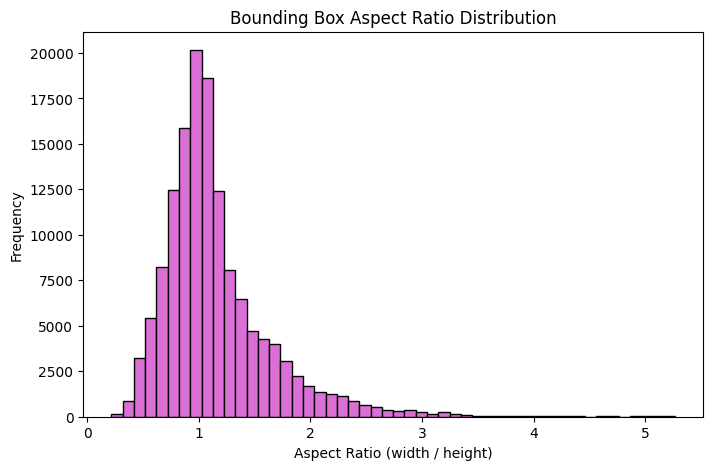

In [ ]:
aspect_ratios = [w/h for w, h in zip(widths, heights) if h > 0]

plt.figure(figsize=(8,5))
plt.hist(aspect_ratios, bins=50, color='orchid', edgecolor='black')
plt.xlabel('Aspect Ratio (width / height)')
plt.ylabel('Frequency')
plt.title('Bounding Box Aspect Ratio Distribution')
plt.show()

**Bounding Box Aspect Ratio Distribution**

The histogram above shows the distribution of bounding box aspect ratios (width divided by height) across all annotated objects in the training set.

- **Peak at aspect ratio ≈ 1**  
  The highest frequency occurs around a ratio of 1.0, indicating that most objects are roughly square in shape. This is expected for many satellite components, debris fragments, and spherical objects when look from a long distance.

- **Long tail toward higher aspect ratios**  
  Although the frequency drops sharply as the aspect ratio increases, there is still a notable number of elongated objects (ratios of 2, 3, and even 4–5). These correspond to elongated satellite structures (e.g., cylindrical bodies, solar panels, antenna booms) or irregular debris.

- **Insight for size estimation**  
  When estimating the real‑world size of debris from its bounding box, the aspect ratio provides a clue about the object’s shape. Combined with distance information, it can help determine whether the object is compact or elongated, which may influence how the collector should approach it.

Spatial Distribution of Objects (Heatmap) - Where in the image do objects tend to appear? We plot the centers of all bounding boxes.



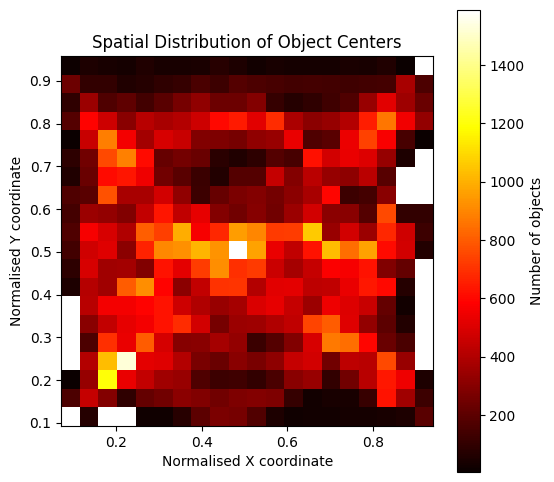

In [ ]:
# Get image dimensions from a sample image (assuming all images have the same size)
sample_img_info = coco_train.loadImgs(img_ids[0])[0]
img_w = sample_img_info['width']
img_h = sample_img_info['height']

centers_x = []
centers_y = []

for ann in coco_train.loadAnns(ann_ids):
    bbox = ann['bbox']
    x, y, w, h = bbox
    centers_x.append(x + w/2)
    centers_y.append(y + h/2)

# Normalise to [0,1]
norm_x = [cx / img_w for cx in centers_x]
norm_y = [cy / img_h for cy in centers_y]

plt.figure(figsize=(6,6))
plt.hist2d(norm_x, norm_y, bins=20, cmap='hot', cmin=1)
plt.colorbar(label='Number of objects')
plt.xlabel('Normalised X coordinate')
plt.ylabel('Normalised Y coordinate')
plt.title('Spatial Distribution of Object Centers')
plt.gca().set_aspect('equal')
plt.show()

**Spatial Distribution of Object Centers**

The heatmap above visualizes the **center coordinates** of all bounding boxes across the training set, normalized to the image dimensions (0 = left/top, 1 = right/bottom). The color intensity indicates the density of object centers in each region.

- **Center‑biased concentration**  
  Most object centers are concentrated near the center of the image (around x = 0.5, y = 0.5), with a sharp drop toward the edges. This is common in datasets where objects are often placed centrally to simplify labeling and ensure they are fully visible.

- **Slight asymmetry**  
  There appears to be a slight preference for the right and lower‑left quadrant (higher x and y). This might be due to specific camera angles or composition choices in the synthetic generation process.

- **Implications for model generalization**  
  A strong center bias can lead the model to become “position‑sensitive” – i.e., it may perform worse when debris appears near image boundaries. To mitigate this, we included augmentations like random translation, mosaic, and rotation during training, which artificially place objects in all parts of the image. This helps the model learn to detect debris regardless of its position.


Modify the COCO Category Mapping -
Create a new category map where all satellite types (10 classes) and spacerock map to ID 0 (non‑debris), and spacedebris maps to ID 1 (debris).

In [ ]:
# Original category IDs (as seen in your dataset)
# Manually define which IDs become non‑debris (0) and which become debris (1)
CAT_MAP = {
    1: 0,   # Cubesat → non‑debris
    2: 0,   # Cylindrical_satellite
    3: 0,   # GEO_communication_satellite
    4: 0,   # LEO_communication_satellite
    5: 0,   # Navigation_satellite
    6: 0,   # SAR_satellite
    7: 0,   # Single_panel_Earth_observation_satellite
    8: 0,   # Symmetrical_Earth_Observation_Satellite
    9: 0,   # Space_Probe
    10: 0,  # Space_Telescope
    11: 1,  # spacedebris → debris
    12: 1,  # spacerock → debris
}

Load and remap on the fly during training

In [ ]:
import torch
import os
from PIL import Image
from torchvision import transforms

class BinaryDebrisDataset(torch.utils.data.Dataset):
    """COCO dataset with binary mapping: non‑debris (0) / debris (1)."""
    def __init__(self, coco, img_dir, transform=None):
        """
        Args:
            coco: pycocotools.coco.COCO object (already loaded).
            img_dir: path to the folder containing images.
            transform: torchvision transform to apply to images.
        """
        self.coco = coco
        self.img_dir = img_dir
        self.transform = transform
        self.img_ids = coco.getImgIds()

        # Build mapping from original category id to binary (0/1)
        self.cat_map = CAT_MAP   # use predefined mapping

    def __len__(self):
        return len(self.img_ids)

    def __getitem__(self, idx):
        # Get image ID and load image
        img_id = self.img_ids[idx]
        img_info = self.coco.loadImgs(img_id)[0]
        img_path = os.path.join(self.img_dir, img_info['file_name'])
        image = Image.open(img_path).convert('RGB')

        # Load annotations for this image
        ann_ids = self.coco.getAnnIds(imgIds=img_id)
        anns = self.coco.loadAnns(ann_ids)

        # Prepare targets: boxes (xywh) and labels (binary)
        boxes = []
        labels = []
        for ann in anns:
            # Remap category
            orig_cat = ann['category_id']
            if orig_cat not in self.cat_map:
                continue  # skip if unknown category
            label = self.cat_map[orig_cat]

            # COCO bbox format: [x, y, width, height]
            x, y, w, h = ann['bbox']
            boxes.append([x, y, w, h])
            labels.append(label)

        # Convert to tensors
        boxes = torch.as_tensor(boxes, dtype=torch.float32)
        labels = torch.as_tensor(labels, dtype=torch.int64)

        # Create target dictionary (standard for torchvision detection)
        target = {
            'boxes': boxes,
            'labels': labels,
            'image_id': torch.tensor([img_id]),
            'area': (boxes[:, 2] * boxes[:, 3]),  # width * height
            'iscrowd': torch.zeros((len(boxes),), dtype=torch.int64),
        }

        # Apply transforms (if any)
        if self.transform:
            image = self.transform(image)

        return image, target

Check Binary Class Distribution -


loading annotations into memory...
Done (t=1.47s)
creating index...
index created!
Original categories:
  ID 1: Cubesat
  ID 2: Cylindrical_satellite
  ID 3: GEO_communication_satellite
  ID 4: LEO_communication_satellite
  ID 5: Navigation_satellite
  ID 6: SAR_satellite
  ID 7: Single_panel_Earth_observation_satellite
  ID 8: Symmetrical_Earth_Observation_Satellite
  ID 9: Space_Probe
  ID 10: Space_Telescope
  ID 11: spacedebris
  ID 12: spacerock

Debris category ID: 11

📊 Original class distribution:
  Cubesat: 6997 instances
  Cylindrical_satellite: 7024 instances
  GEO_communication_satellite: 7000 instances
  LEO_communication_satellite: 6958 instances
  Navigation_satellite: 7007 instances
  SAR_satellite: 7026 instances
  Single_panel_Earth_observation_satellite: 7070 instances
  Symmetrical_Earth_Observation_Satellite: 6980 instances
  Space_Probe: 6922 instances
  Space_Telescope: 7000 instances
  spacedebris: 42053 instances
  spacerock: 27963 instances

🔢 Binary class dis

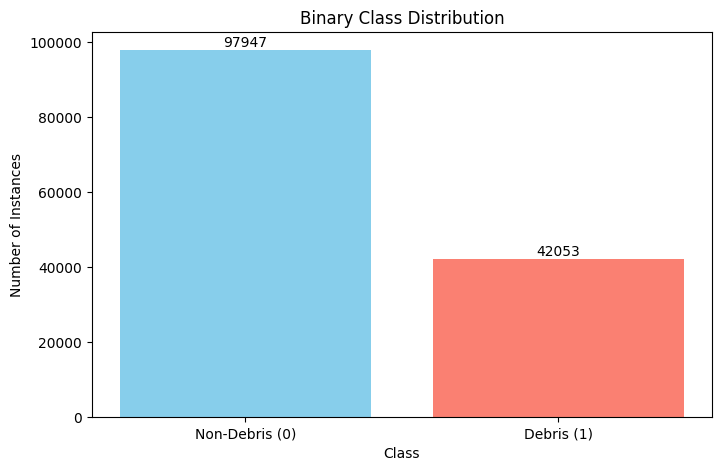


⚖️ Recommended class weights for loss function:
  Class 0 weight: 0.7147
  Class 1 weight: 1.6646


In [ ]:
from pycocotools.coco import COCO
from collections import Counter
import matplotlib.pyplot as plt

# Load your training annotations
coco = COCO(ann_train)   # ann_train is the path to train.json

# Display original categories
cat_ids = coco.getCatIds()
categories = coco.loadCats(cat_ids)
print("Original categories:")
for cat in categories:
    print(f"  ID {cat['id']}: {cat['name']}")

# Count original distribution
ann_ids = coco.getAnnIds()
anns = coco.loadAnns(ann_ids)
orig_counts = Counter([ann['category_id'] for ann in anns])

print("\n📊 Original class distribution:")
for cat_id, count in sorted(orig_counts.items()):
    cat_name = next((c['name'] for c in categories if c['id'] == cat_id), "Unknown")
    print(f"  {cat_name}: {count}")

# Binary mapping (using CAT_MAP defined earlier)
binary_counts = {0: 0, 1: 0}
for ann in anns:
    new_label = CAT_MAP.get(ann['category_id'])
    if new_label is not None:
        binary_counts[new_label] += 1

print("\n🔢 Binary class distribution (after remapping):")
print(f"  Non-Debris (class 0): {binary_counts[0]}")
print(f"  Debris (class 1): {binary_counts[1]}")

# Compute imbalance and recommended weights
total = sum(binary_counts.values())
debris_pct = (binary_counts[1] / total) * 100
print(f"\nDebris is {debris_pct:.2f}% of all instances")

if binary_counts[0] > 0 and binary_counts[1] > 0:
    w0 = total / (2 * binary_counts[0])
    w1 = total / (2 * binary_counts[1])
    print("\n⚖️ Recommended class weights for loss function:")
    print(f"  Class 0 (non‑debris): {w0:.4f}")
    print(f"  Class 1 (debris): {w1:.4f}")

# Visualise
plt.figure(figsize=(8,5))
plt.bar(['Non-Debris (0)', 'Debris (1)'], [binary_counts[0], binary_counts[1]],
        color=['skyblue', 'salmon'])
plt.xlabel('Class')
plt.ylabel('Number of Instances')
plt.title('Binary Class Distribution')
for i, count in enumerate([binary_counts[0], binary_counts[1]]):
    plt.text(i, count + max(binary_counts.values())*0.01, str(count), ha='center')
plt.show()